In [105]:
import sympy as sym
import numpy as np
import scipy as sp
from scipy import linalg,spatial,signal
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

**DEFINICIJA OKVIRJA**

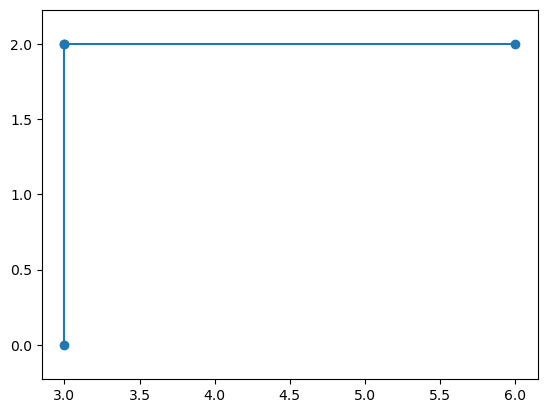

In [106]:
#OKVIR 
L = 3 #m
H = 2 #m
h_A = 0.1 #m
ρ_A = 7850 # kg /m3
E_A = 2e11 # Pa
A_A = h_A*h_A # m^2
I_A = (h_A*h_A**3)/12 # m^4

# vozlišča in elementi 
vozlisca_n = np.array([[L,0],[L,H],[L+L,H]])
elementi_n = np.array ([[0,1],[1,2]])
[plt.plot(vozlisca_n[e,0],vozlisca_n[e,1],'-o',c='C0') for e in elementi_n]
plt.axis('equal');

In [107]:
# zgostitev mreže in prikaz  - Okvir 
n1 = 7
n2 = 10

vozlisca_AB=np.array([[L,y] for y in np.linspace(0,H,n1)])
vozlisca_BC=np.array([[x+L,H] for x in np.linspace(0,L,n2)])

Text(0, 0.5, 'y [m]')

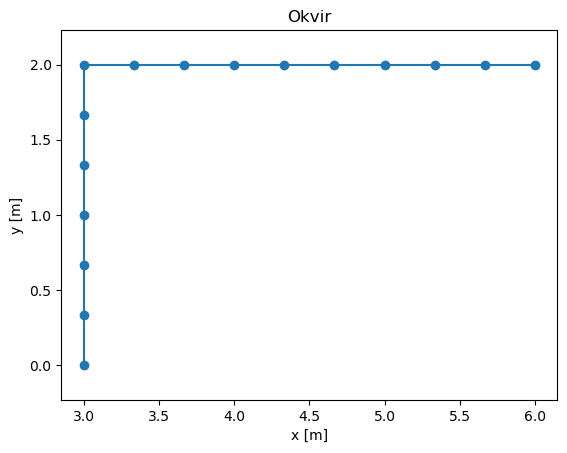

In [108]:
vozlisca_SK_n = np.vstack([vozlisca_AB,vozlisca_BC[1:]])

elementi_SK_n = np.array([[i,i+1] for i in range(len(vozlisca_SK_n)-1) ])  #vsi elementi zaporedoma

[plt.plot(vozlisca_SK_n[[i,j],0],vozlisca_SK_n[[i,j],1],'-',c='C0') for i,j in elementi_SK_n]
plt.plot(vozlisca_SK_n[:,0],vozlisca_SK_n[:,1],'o');
plt.axis('equal');

plt.title("Okvir")
plt.xlabel('x [m]')
plt.ylabel('y [m]')

**DEFINICIJA PALIČJA**

Text(0, 0.5, 'y [m]')

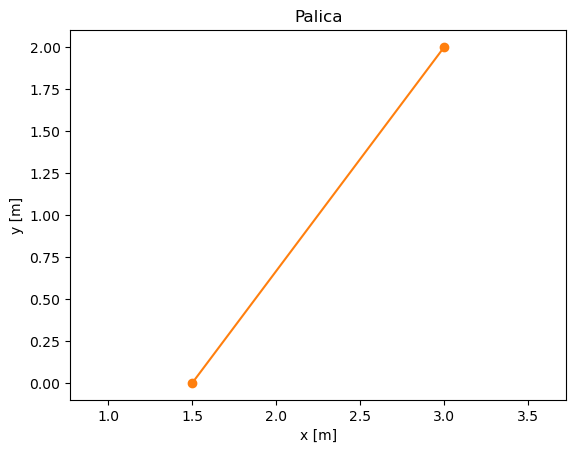

In [109]:
# Pdatki za PALIČJE in prikaz
d = 0.05
E_p = 2e11 # Pa
A_p = np.pi * d**2 / 4 # m^2
ρ_p = 7850 # kg /m3
E_P = 2e11 # Pa
L = 3.0 #m
H = 2.0 #m

vozlisca_p = np.array([[L/2,0],[L,H]])
elementi_p = np.array([[0,1]])

[plt.plot(vozlisca_p[e,0],vozlisca_p[e,1],'-o',c='C1') for e in elementi_p]
plt.axis('equal');

plt.title("Palica")
plt.xlabel('x [m]')
plt.ylabel('y [m]')

In [110]:
# Lokalna masna in togostna matrika za okvir + transformacijska matrika - OKVIR
def T(α):
    
    T = np.array([[ np.cos(α), np.sin(α), 0,         0,         0, 0],
                   [-np.sin(α), np.cos(α), 0,         0,         0, 0],
                   [         0,         0, 1,         0,         0, 0],
                   [         0,         0, 0, np.cos(α), np.sin(α), 0],
                   [         0,         0, 0,-np.sin(α), np.cos(α), 0],
                   [         0,         0, 0,         0,         0, 1]])
        
    return T

# masna matrika
def M_o(A, L, ρ, α):

    M_lok = ρ*A*L*np.array([[1/3,         0,         0, 1/6,         0,         0],
                            [  0,     13/35,  11*L/210,   0,      9/70, -13*L/420],
                            [  0,  11*L/210,  L**2/105,   0,  13*L/420, -L**2/140],
                            [1/6,         0,         0, 1/3,         0,         0],
                            [  0,      9/70,  13*L/420,   0,     13/35, -11*L/210],
                            [  0, -13*L/420, -L**2/140,   0, -11*L/210,  L**2/105]])
    
    return T(α).T @ M_lok @ T(α)

# togostna matrika
def K_o(A, E, I, L, α):

    K_lok = E/L*np.array([[ A,          0,      0, -A,          0,      0],
                          [ 0,  12*I/L**2,  6*I/L,  0, -12*I/L**2,  6*I/L],
                          [ 0,      6*I/L,    4*I,  0,     -6*I/L,    2*I],
                          [-A,          0,      0,  A,          0,      0],
                          [ 0, -12*I/L**2, -6*I/L,  0,  12*I/L**2, -6*I/L],
                          [ 0,      6*I/L,    2*I,  0,     -6*I/L,    4*I]])
    
    return T(α).T @ K_lok @ T(α)

In [111]:
# 1. Lokalna masna matrika v lokalnem koordinatem sistemu - Paličje
# 2. Lokalna masna matrika v globalnem koordinatnem sistemu - Paličje
# M_lok_lok = M_lok
def M_p(A, L, ρ):
    
    M = (ρ*A*L/6)*np.array([
        [2, 0, 1, 0],
        [0, 2, 0, 1],
        [1, 0, 2, 0],
        [0, 1, 0, 2]])
    return M


# 1. Lokalna togostna matrika v lokalnem koordinatnem sistemu
# 2. Lokalna togostna matrika v globalnem koordinatem sistemu -> K_lok
def K_p(A, E, L, α):

    c = np.cos(α)
    s = np.sin(α)
    
    K = A*E/L*np.array([
    [ c**2,   s*c, -c**2,  -s*c],
    [  s*c,  s**2,  -s*c, -s**2],
    [-c**2,  -s*c,  c**2,   s*c],
    [ -c*s, -s**2,   s*c,  s**2]])
    
    return K

In [112]:
# Globalna masna in togostna matrika - OKVIR
n_ps_n = 3*len(vozlisca_SK_n)
M_glob_n = np.zeros((n_ps_n,n_ps_n))
K_glob_n = np.zeros((n_ps_n,n_ps_n))

for element in elementi_SK_n:
    Le_n = sp.spatial.distance.euclidean(vozlisca_SK_n[element[0]], vozlisca_SK_n[element[1]])
    αe_n = np.arctan2(np.diff(vozlisca_SK_n[element,1]) , np.diff(vozlisca_SK_n[element,0]))[0]
    ind_n = (3*element[:,None] + np.array([0, 1, 2])).flatten()
    
    M_glob_n[ind_n[:,None],ind_n] += M_o(A_A, Le_n, ρ_A, αe_n)
    K_glob_n[ind_n[:,None],ind_n] += K_o(A_A, E_A, I_A, Le_n, αe_n)

In [113]:
# Paličje:
# Prehod iz lokalne masne in togostne matrike v globalen KO sistemu v
# globalno masno in togostno matriko v globalnem KO sistemu
n_ps_p = 2*len(vozlisca_p)
M_glob_p = np.zeros((vozlisca_p.size, vozlisca_p.size))
K_glob_p = np.zeros((vozlisca_p.size, vozlisca_p.size))

for element_p in elementi_p:
    # dolžina elementa
    Le_p = sp.spatial.distance.euclidean(vozlisca_p[element_p[0]], vozlisca_p[element_p[1]])
    
    # kot zasuka
    αe_p = np.arctan2(np.diff(vozlisca_p[element_p,1]), np.diff(vozlisca_p[element_p,0]))[0]
    
    # indeksi prostostnih stopenj
    ind_p = (2*element_p[:,None] + np.array([0,1])).flatten()
    
    # prištevanje prispvkov posameznih elementov
    M_glob_p[ind_p[:,None], ind_p] += M_p(A_p, Le_p, ρ_p)
    K_glob_p[ind_p[:,None], ind_p] += K_p(A_p, E_p, Le_p, αe_p)

**robni pogoji - okvir**

In [114]:
#robni pogoji - vpetje - OKVIR
ind_vp_ps_n = np.array([0, 1, 2])

C_n_rp = np.zeros((len(ind_vp_ps_n),n_ps_n))
C_n_rp[np.arange(len(ind_vp_ps_n)),ind_vp_ps_n] = 1

**robni pogoji - paličje**

In [115]:
# Robni pogji, vpetje - Paličje
ind_vpetih_ps_p = np.array([0,1])
ind_ps_p = np.arange(2*len(vozlisca_p))

C_p_rp = np.zeros((len(ind_vpetih_ps_p),n_ps_p))
C_p_rp[np.arange(len(ind_vpetih_ps_p)),ind_vpetih_ps_p] = 1
C_p_rp.shape

(2, 4)

In [116]:
#Robni pogoji OKVIRJA IN PALIČJA
C_rp = sp.linalg.block_diag(C_n_rp,C_p_rp)

**povezava okvirja in paličja**

In [117]:
#povezava OKVIRJA in PALIČJA
C_n_pov = np.zeros((2,n_ps_n))
C_n_pov[[0,1],[18,19]] = 1

C_p_pov = np.zeros((2,n_ps_p))
C_p_pov[[0,1],[2,3]] = -1

C_pov = np.hstack([C_n_pov,C_p_pov]) 

In [118]:
n_ps_n, n_ps_p, C_pov.shape

(48, 4, (2, 52))

In [119]:
# Povezovalna matrika C in matrika L za OKVIR in PALIČJE
C = np.vstack([C_rp, C_pov])
L = sp.linalg.null_space(C);
L.shape

(52, 45)

In [120]:
# Globalna masna in togostna matrika za OKVIR in PALIČJE
M_glob = L.T @ sp.linalg.block_diag(M_glob_n, M_glob_p) @ L
K_glob = L.T @ sp.linalg.block_diag(K_glob_n, K_glob_p) @ L

**PROBLEM LASTNIH VREDNOSTI**

In [121]:
# Reševanje problema lastnih vrednosti in lastnih vektorjev
eig_val, eig_vec = sp.linalg.eig(K_glob, M_glob)
_ind = np.argsort(np.abs(eig_val))
eig_val = np.abs(eig_val[_ind])
eig_vec = eig_vec[:,_ind]
eig_freq = np.abs(eig_val)**0.5 / 2 / np.pi
eig_vec_n = L[:n_ps_n,:] @ eig_vec  
eig_vec_p = L[-n_ps_p:,:] @ eig_vec

In [122]:
# Izpis prvih petih lastnih krožnih frekvenc
eig_freq[:5].round(2)

array([  6.94,  46.68,  65.07, 109.71, 151.34])

**IZRIS LASTNIH OBLIK**

Text(0, 0.5, 'y [m]')

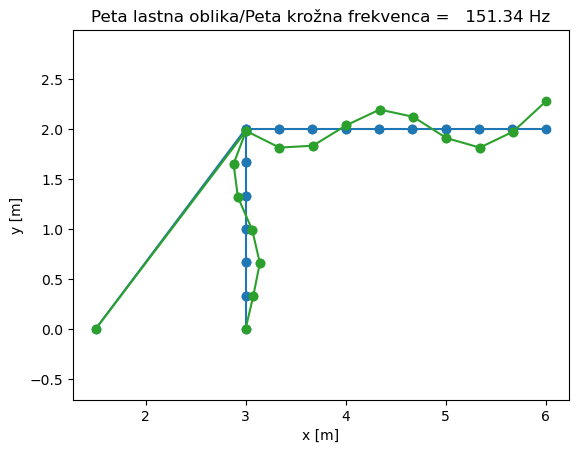

In [123]:
# animacija lastnih oblik
m = 5
s = 2


# Podstruktrura Okvir
pomiki_x_n = eig_vec_n[0::3,m].real
pomiki_y_n = eig_vec_n[1::3,m].real

# podstruktura Paličje
pomiki_x_p = eig_vec_p[0::2,m].real
pomiki_y_p = eig_vec_p[1::2,m].real

# stacionarni izris
def_vozlisca_n = np.copy(vozlisca_SK_n)
def_vozlisca_n[:,0] += pomiki_x_n * s
def_vozlisca_n[:,1] += pomiki_y_n * s

def_vozlisca_p = np.copy(vozlisca_p)
def_vozlisca_p[:,0] += pomiki_x_p * s
def_vozlisca_p[:,1] += pomiki_y_p * s

# osnovno stanje
plt.axis('equal')
[plt.plot(*vozlisca_SK_n[e].T,'-o',c='C0') for e in elementi_SK_n];
[plt.plot(*vozlisca_p[e].T,'-o',c='C0') for e in elementi_p];

# deformirano stanje
plt.axis('equal')
[plt.plot(*def_vozlisca_n[e].T,'-o',c='C2')for e in elementi_SK_n];
[plt.plot(*def_vozlisca_p[e].T,'-o',c='C2')for e in elementi_p];
plt.xlabel('x')
plt.ylabel('y')
plt.title("Peta lastna oblika/Peta krožna frekvenca =   151.34 Hz")
plt.xlabel('x [m]')
plt.ylabel('y [m]')

**HARMONSKA ANALIZA**

In [124]:
# masno normiranje
m_rr = np.diagonal(eig_vec.T @ M_glob @ eig_vec)
Φ = eig_vec / m_rr**0.5

ω_r = eig_val**0.5

In [125]:
vozlisca = np.vstack([vozlisca_SK_n,vozlisca_p])
L_ = 6.0
H_ = 2.0

In [126]:
vozlisca_SK_n.shape, vozlisca_p.shape

((16, 2), (2, 2))

In [127]:
#Harmonska analiza
tocka_prijemanja = np.array([L_,H_])
ind_vozlisca = np.where((vozlisca[:,None] == tocka_prijemanja).all(2).flatten())[0] 
ind_x, ind_y, ind_phi = 3*ind_vozlisca[0] + [0,1,2]
#ind_x, ind_y, ind_phi = [3,4,5]


F1y = 4000; 
f_glob = np.zeros(3*len(vozlisca_SK_n)+2*len(vozlisca_p)) # pazi na robne pogoje
f_glob[ind_y] = F1y


f_glob = np.linalg.pinv(L) @ f_glob # prehod v svet Q
h_r = Φ.T @ f_glob # prehod v fizikalni svet

In [128]:
f_glob.shape

(45,)

In [129]:
st_mod = len(ω_r)

δ = 0.003  # konstanten za vse lastne frekvence
ω = np.arange(2000) # gledamo ko se omega spreminja od 1 do 1999 rad/s
H_h = np.zeros([st_mod,ω.shape[0]]) # toliko kot je prostostnih stopenj in kot je frekvenčnih vzbujanj
phi_h = np.zeros([st_mod,ω.shape[0]])

for i in range(st_mod):
    H_h[i] = h_r[i]/ω_r[i]**2 * 1/((1-(ω/ω_r[i])**2)**2+(2*δ*ω/ω_r[i])**2)**0.5  # amplitudni odziv

    phi_h[i] = -np.arctan2(-2*δ*ω/ω_r[i], 1-(ω/ω_r[i])**2)    # fazni zamik
    
# prehod v fizikalni prostor
H_fiz = L @ Φ @ (H_h*np.exp(1.j*phi_h)) # amplitudo pomnožimo z Eulerjem (vsebuje amplitudo in fazo)

In [130]:
ω_r[:5].round(2) # [rad/s] prvih 5 lastnih krožnih frekvenc 

array([ 43.61, 293.32, 408.82, 689.33, 950.87])

**AMPLITUDNI IN FAZNI SPEKTER**

Text(0.5, 0, 'ω [rad]')

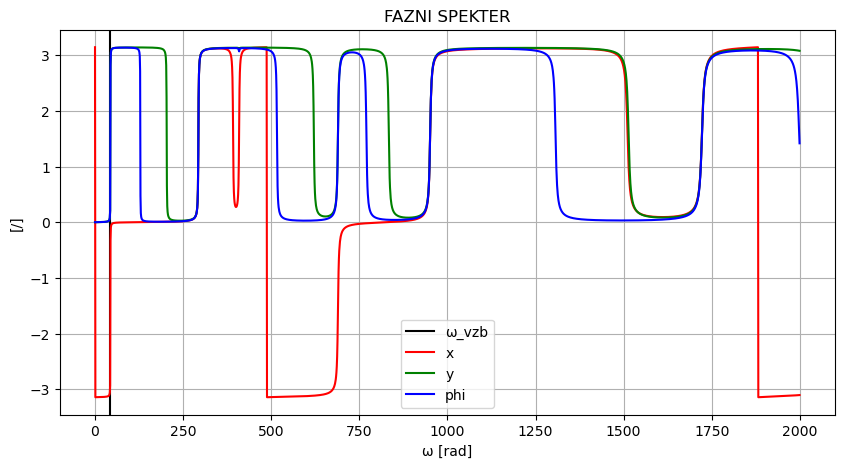

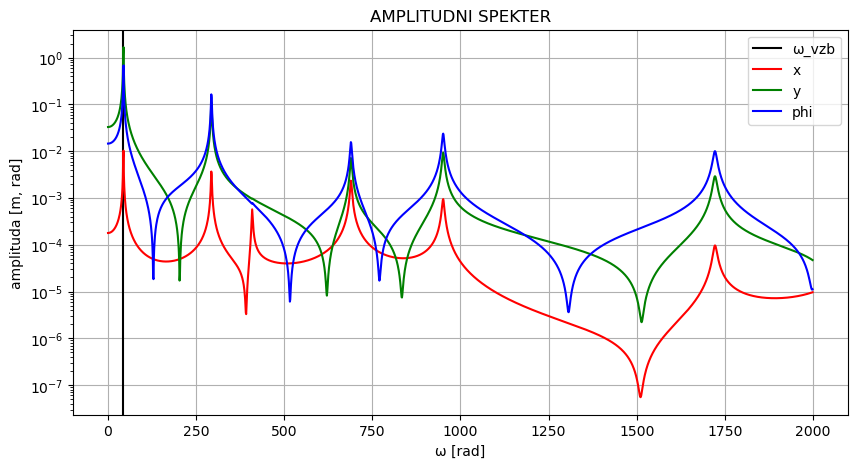

In [131]:
ω_vzb = 43

# izris odziva faznega sprektra
plt.figure(figsize=(10,5))
plt.axvline(ω_vzb,c='black',label='ω_vzb')
plt.plot(ω, np.angle(H_fiz[ind_x]),'r',label='x')
plt.plot(ω, np.angle(H_fiz[ind_y]),'g',label='y')
plt.plot(ω, np.angle(H_fiz[ind_phi]),'b',label='phi')
plt.legend()
plt.grid()
plt.title("FAZNI SPEKTER")
plt.xlabel("ω [rad]")
plt.ylabel("[/]")

# izris odziva amplitudnega spektra
plt.figure(figsize=(10,5))
plt.axvline(ω_vzb,c='black', label='ω_vzb')
plt.semilogy(ω, np.abs(H_fiz[ind_x]),'r',label='x')     #izrišemo v log skali, enote so v m
plt.semilogy(ω, np.abs(H_fiz[ind_y]),'g',label='y')
plt.semilogy(ω, np.abs(H_fiz[ind_phi]),'b',label='phi')
plt.legend()
plt.grid()
plt.title("AMPLITUDNI SPEKTER")
plt.ylabel("amplituda [m, rad]")
plt.xlabel("ω [rad]")


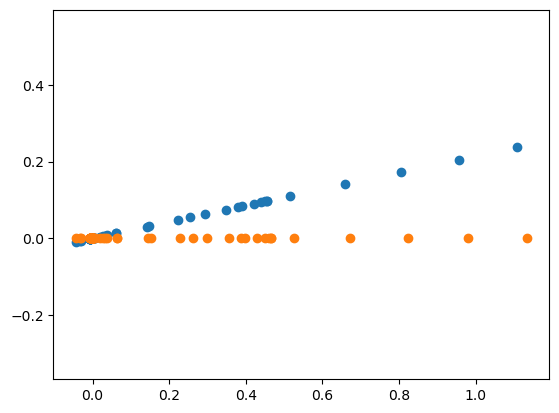

In [132]:
odziv = H_fiz[:, np.where(ω == ω_vzb)[0]].flatten()

def f(x, k):
    return k * x

k, _ = curve_fit(f, odziv.real, odziv.imag)

odziv_ = odziv * np.exp(-1.j*np.arctan(k))

odziv_plot = np.sign(odziv_) * np.abs(odziv_)

plt.plot(odziv.real, odziv.imag,'o')
plt.plot(odziv_.real, odziv_.imag,'o')
plt.axis('equal');

**PRIKAZ LASTNIH OBLIK - HARMONSKA ANALIZA**

In [133]:
# izbrali smo vzbujevalno frekvenco blizu ene od lastnih krožnih frekvenc
ω_vzb = 43
odziv = H_fiz[:, np.where(ω == ω_vzb)[0]].real.flatten()

#ločimo odziv paličja in okvirja
odziv_A = odziv[:(n_ps_n)]
odziv_B = odziv[(n_ps_n):]

In [134]:
# iz odzivov posamezne podstrukture razberemo pomike v x in y smeri
pomiki_x_A = odziv_A[0::3]
pomiki_y_A = odziv_A[1::3]

pomiki_x_B = odziv_B[0::2]
pomiki_y_B = odziv_B[1::2]

scale = 1 # skalirni faktor je 1, ker gledamo dejanski, fizikalni odziv pri določeni frekvenci

# pomike prištejemo h koordinatam nedeformiranega vozlišča
def_vozlisca_A = np.copy(vozlisca_SK_n)
def_vozlisca_A[:,0] += pomiki_x_A*scale
def_vozlisca_A[:,1] += pomiki_y_A*scale

def_vozlisca_B = np.copy(vozlisca_p)
def_vozlisca_B[:,0] += pomiki_x_B*scale
def_vozlisca_B[:,1] += pomiki_y_B*scale

odziv.shape  #odziv za vsa vozlišča


(52,)

Text(0, 0.5, 'y [m]')

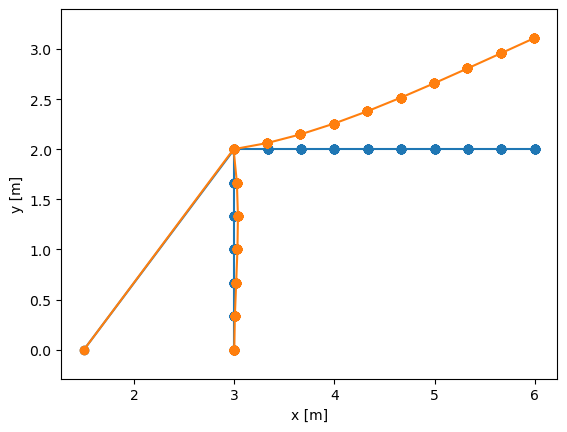

In [135]:
# nedeformirano stanje
for i,j in elementi_SK_n:
    plt.plot(vozlisca_SK_n[[i,j],0],vozlisca_SK_n[[i,j],1],'-',c='C0') 
    plt.plot(vozlisca_SK_n[:,0],vozlisca_SK_n[:,1],'o',c='C0');
    
for i,j in elementi_p:
    plt.plot(vozlisca_p[[i,j],0],vozlisca_p[[i,j],1],'-', c='C0') 
    plt.plot(vozlisca_p[:,0],vozlisca_p[:,1],'o', c='C0');

# deformirano stanje
for i,j in elementi_SK_n:
    plt.plot(def_vozlisca_A[[i,j],0],def_vozlisca_A[[i,j],1],'-',c='C1')
    plt.plot(def_vozlisca_A[:,0],def_vozlisca_A[:,1],'o',c='C1');

for i,j in elementi_p:
    plt.plot(def_vozlisca_B[[i,j],0],def_vozlisca_B[[i,j],1],'-', c='C1')
    plt.plot(def_vozlisca_B[:,0],def_vozlisca_B[:,1],'o', c='C1');

plt.axis('equal');
plt.xlabel("x [m]")
plt.ylabel("y [m]")

**NUMERIČNA INTEGRACIJA**

**definicija vzbujanja**

In [150]:
t0 = 0.5 # čas impulza v [s]
F0 = 400 # amplituda v [N]
ind_vozlisca = 16
ind_x = 47#ind_vozlisca * 3 -2# mesto delovanja
# index 50 je vzbujanje v x smeri v vozlišču kjer sta strukturi skupaj
# index 47 je v y smeri na koncu nosilca (če se ne motim)

In [151]:
def f_glob_AB(t):
    f_glob = np.zeros(3*len(vozlisca)-2)
    if t < t0:
        f_imp = F0*np.sin(np.pi*t/t0)
    else:
        f_imp = 0  
    f_glob[ind_x] = f_imp
    # print(f_glob.shape)
    return L.T @ f_glob

In [152]:
f_glob_AB(0.2)

array([  0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,   0.        ,   0.        ,   0.        ,
       380.42260652,   0.        ,   0.        ,   0.        ,
         0.        ])

**definicija dušenja in začetnih pogojev**

In [153]:
# definiramo dušenje
α = 5e-1
β = 3e-2
C_glob = α*M_glob + β*K_glob  # narejena s proporcionalnim dušenjem 

# zložimo matriko D (DE 1. reda)
D = np.block([[-np.linalg.inv(M_glob) @ C_glob , -np.linalg.inv(M_glob) @ K_glob],
              [np.eye(M_glob.shape[0]) , np.zeros_like(M_glob)]])



In [154]:
def integrirate(t,v):
    F = np.block([np.linalg.inv(M_glob)@f_glob_AB(t),np.zeros_like(f_glob_AB(t))])
    return D @ v + F

In [155]:
# Definiramo začetne pogoje - najlažje je če predpostavimo da konstrukcija na začetku miruje (naredimo ničelne matrike)
Q_0 = np.zeros(M_glob.shape[0])
Q1_0 = np.zeros(M_glob.shape[0])

# združeni začetni pogoji - pomiki in hitrosti
q0 = np.hstack([Q1_0, Q_0])

**reševanje**

In [156]:
# definiramo časovni okvir v katerem gledamo odziv
t_min = 0
t_max = 5
t_1000 = np.linspace(t_min,t_max,1000) # razdelimo na 1000 delov, da bomo imeli dobro rezolucijo rezultatov

# za reševanje glede na začetne vrednosti
resitev = sp.integrate.solve_ivp(integrirate, t_span=(t_1000[0], t_1000[-1]), method='Radau', y0=q0,)  #t_eval  tam bo računal, y0 pa so začetni pogoji

resitev.y.shape


(90, 36)

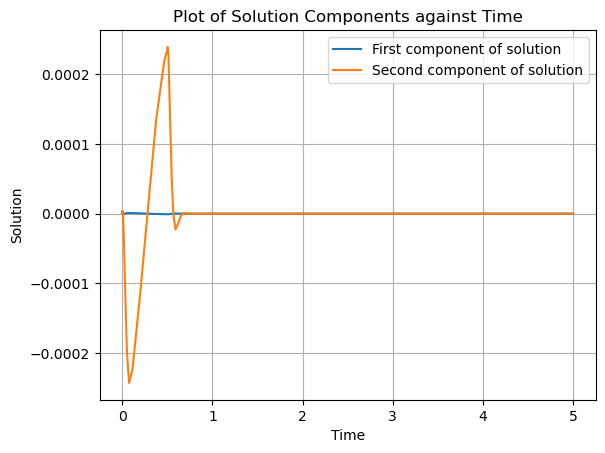

In [157]:
import matplotlib.pyplot as plt

# Extract the time points from the solution
t_eval = resitev.t

# Plot the solution components against time
plt.plot(t_eval, resitev.y[0], label='First component of solution')
plt.plot(t_eval, resitev.y[1], label='Second component of solution')
# Add more plots for additional components if needed

plt.xlabel('Time')
plt.ylabel('Solution')
plt.title('Plot of Solution Components against Time')
plt.legend()
plt.grid(True)
plt.show()
